In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import os
import time
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, recall_score, fbeta_score


In [ ]:

TRAIN_PATH = "/content/drive/MyDrive/Cataract/Data/Train"
TEST_PATH  = "/content/drive/MyDrive/Cataract/Data/Test"

MODEL_PATH = "/content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5"


In [ ]:
print("Train folders:", os.listdir(TRAIN_PATH))
print("Test folders:", os.listdir(TEST_PATH))


Train folders: ['Cataract', 'Normal', 'Not Eye']
Test folders: ['Cataract', 'Normal', 'Not Eye']


In [ ]:
transformation_ratio = 0.05

datagen = ImageDataGenerator(
    rescale = 1. / 255,
    validation_split = 0.2,
    horizontal_flip = True,
    vertical_flip = True
)


In [ ]:
train_it = datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = (224, 224),
    color_mode = 'rgb',
    class_mode = 'categorical',
    batch_size = 32,
    subset = "training"
)

val_it = datagen.flow_from_directory(
    TRAIN_PATH,
    target_size = (224, 224),
    color_mode = 'rgb',
    class_mode = 'categorical',
    batch_size = 32,
    subset = "validation"
)

test_it = datagen.flow_from_directory(
    TEST_PATH,
    target_size = (224, 224),
    color_mode = 'rgb',
    class_mode = 'categorical',
    batch_size = 32,
    shuffle = False
)

print("Class indices:", train_it.class_indices)


Found 8896 images belonging to 3 classes.
Found 2221 images belonging to 3 classes.
Found 2552 images belonging to 3 classes.
Class indices: {'Cataract': 0, 'Normal': 1, 'Not Eye': 2}


In [ ]:
base_model = MobileNetV2(
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    include_top = False
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
ocl1 = Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3))(base_model.output)
bn1 = BatchNormalization()(ocl1)
mp1 = MaxPooling2D(pool_size=(2, 2))(bn1)
do1 = Dropout(0.17)(mp1)

ocl2 = Conv2D(64, (2, 2), activation='relu')(do1)
bn2 = BatchNormalization()(ocl2)

al1 = GlobalAveragePooling2D()(bn2)

fc1 = Dense(64, activation='relu')(al1)
fc2 = Dense(32, activation='relu')(fc1)
fc3 = Dense(32, activation='relu')(fc2)

al2 = BatchNormalization()(fc3)
all2 = Dropout(0.3)(al2)

output = Dense(3, activation='softmax', name='preds')(all2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
Cataract_Model = Model(
    inputs = base_model.input,
    outputs = output
)

Cataract_Model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,642,819 (10.08 MB)

 Trainable params: 2,608,451 (9.95 MB)

 Non-trainable params: 34,368 (134.25 KB)

In [ ]:
Cataract_Model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)


In [ ]:
for ix in range(148):
    Cataract_Model.layers[ix].trainable = False


In [ ]:

for i, layer in enumerate(Cataract_Model.layers):
    print(i, layer.name, layer.trainable)


0 input_layer False
1 Conv1 False
2 bn_Conv1 False
3 Conv1_relu False
4 expanded_conv_depthwise False
5 expanded_conv_depthwise_BN False
6 expanded_conv_depthwise_relu False
7 expanded_conv_project False
8 expanded_conv_project_BN False
9 block_1_expand False
10 block_1_expand_BN False
11 block_1_expand_relu False
12 block_1_pad False
13 block_1_depthwise False
14 block_1_depthwise_BN False
15 block_1_depthwise_relu False
16 block_1_project False
17 block_1_project_BN False
18 block_2_expand False
19 block_2_expand_BN False
20 block_2_expand_relu False
21 block_2_depthwise False
22 block_2_depthwise_BN False
23 block_2_depthwise_relu False
24 block_2_project False
25 block_2_project_BN False
26 block_2_add False
27 block_3_expand False
28 block_3_expand_BN False
29 block_3_expand_relu False
30 block_3_pad False
31 block_3_depthwise False
32 block_3_depthwise_BN False
33 block_3_depthwise_relu False
34 block_3_project False
35 block_3_project_BN False
36 block_4_expand False
37 block_4_

In [ ]:
mc = ModelCheckpoint(
    MODEL_PATH,
    monitor = 'val_accuracy',
    mode = 'max',
    verbose = 1,
    save_best_only = True
)


In [ ]:
history = Cataract_Model.fit(
    train_it,
    epochs = 20,
    validation_data = val_it,
    callbacks = [mc]
)




Epoch 1/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6525 - loss: 0.8547 
Epoch 1: val_accuracy improved from None to 0.94507, saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5
278/278 ━━━━━━━━━━━━━━━━━━━━ 3558s 13s/step - accuracy: 0.7850 - loss: 0.5557 - val_accuracy: 0.9451 - val_loss: 0.1907
Epoch 2/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9246 - loss: 0.2421
Epoch 2: val_accuracy improved from 0.94507 to 0.95498, saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5
278/278 ━━━━━━━━━━━━━━━━━━━━ 614s 2s/step - accuracy: 0.9378 - loss: 0.2119 - val_accuracy: 0.9550 - val_loss: 0.1308
Epoch 3/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9636 - loss: 0.1444
Epoch 3: val_accuracy improved from 0.95498 to 0.97028, saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5
278/278 ━━━━━━━━━━━━━━━━━━━━ 621s 2s/step - accuracy: 0.9649 - loss: 0.1373 - val_accuracy: 0.9703 - val_loss: 0.0880
Epoch 4/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9775 - loss: 0.0943
Epoch 4: val_accuracy improved from 0.97028 to 0.98289, saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5
278/278 ━━━━━━━━━━━━━━━━━━━━ 628s 2s/step - accuracy: 0.9767 - loss: 0.0919 - val_accuracy: 0.9829 - val_loss: 0.0509
Epoch 5/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9859 - loss: 0.0638
Epoch 5: val_accuracy improved from 0.98289 to 0.99100, saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5
278/278 ━━━━━━━━━━━━━━━━━━━━ 627s 2s/step - accuracy: 0.9847 - loss: 0.0655 - val_accuracy: 0.9910 - val_loss: 0.0340
Epoch 6/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9854 - loss: 0.0582
Epoch 6: val_accuracy did not improve from 0.99100
278/278 ━━━━━━━━━━━━━━━━━━━━ 703s 2s/step - accuracy: 0.9859 - loss: 0.0561 - val_accuracy: 0.9865 - val_loss: 0.0370
Epoch 7/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9874 - loss: 0.0476
Epoch 7: val_accuracy improved from 0.99100 to 0.99370, saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5
278/278 ━━━━━━━━━━━━━━━━━━━━ 628s 2s/step - accuracy: 0.9875 - loss: 0.0499 - val_accuracy: 0.9937 - val_loss: 0.0213
Epoch 8/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9903 - loss: 0.0395
Epoch 8: val_accuracy did not improve from 0.99370
278/278 ━━━━━━━━━━━━━━━━━━━━ 678s 2s/step - accuracy: 0.9894 - loss: 0.0427 - val_accuracy: 0.9937 - val_loss: 0.0187
Epoch 9/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9924 - loss: 0.0339
Epoch 9: val_accuracy improved from 0.99370 to 0.99415, saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5
278/278 ━━━━━━━━━━━━━━━━━━━━ 610s 2s/step - accuracy: 0.9919 - loss: 0.0340 - val_accuracy: 0.9941 - val_loss: 0.0229
Epoch 10/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9908 - loss: 0.0339
Epoch 10: val_accuracy did not improve from 0.99415
278/278 ━━━━━━━━━━━━━━━━━━━━ 607s 2s/step - accuracy: 0.9910 - loss: 0.0335 - val_accuracy: 0.9923 - val_loss: 0.0231
Epoch 11/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9932 - loss: 0.0276
Epoch 11: val_accuracy did not improve from 0.99415
278/278 ━━━━━━━━━━━━━━━━━━━━ 605s 2s/step - accuracy: 0.9937 - loss: 0.0269 - val_accuracy: 0.9662 - val_loss: 0.1110
Epoch 12/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9918 - loss: 0.0296
Epoch 12: val_accuracy improved from 0.99415 to 0.99595, saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5



Epoch 12: finished saving model to /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5
278/278 ━━━━━━━━━━━━━━━━━━━━ 605s 2s/step - accuracy: 0.9911 - loss: 0.0330 - val_accuracy: 0.9959 - val_loss: 0.0090
Epoch 13/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9948 - loss: 0.0234
Epoch 13: val_accuracy did not improve from 0.99595
278/278 ━━━━━━━━━━━━━━━━━━━━ 632s 2s/step - accuracy: 0.9936 - loss: 0.0253 - val_accuracy: 0.9919 - val_loss: 0.0254
Epoch 14/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9950 - loss: 0.0192
Epoch 14: val_accuracy did not improve from 0.99595
278/278 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - accuracy: 0.9934 - loss: 0.0225 - val_accuracy: 0.9955 - val_loss: 0.0144
Epoch 15/20
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9938 - loss: 0.0237
Epoch 15: val_accuracy did not improve from 0.99595
278/278 ━━━━━━━━━━━━━━━━━━━━ 627s 2s/step - accuracy: 0.9929 - loss: 0.0249 - val_accuracy: 0.9946 - val_loss: 0.0168
Epoch 16/20
278/278 ━━

In [ ]:

best_model = tf.keras.models.load_model(MODEL_PATH)
print("Best model loaded:", MODEL_PATH)


Best model loaded: /content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5


In [ ]:

test_loss, test_accuracy = best_model.evaluate(test_it)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1322s 17s/step - accuracy: 0.9969 - loss: 0.0101
Test Loss: 0.010061360895633698
Test Accuracy: 0.9968652129173279


In [ ]:
test_it.reset()

y_pred_probs = best_model.predict(test_it)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_it.classes

recall = recall_score(y_true, y_pred, average='weighted')
f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted')

print("Recall:", recall)
print("F2 Score:", f2)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_it.class_indices.keys())
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))



80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step
Recall: 0.9945141065830722
F2 Score: 0.994515276064622

Classification Report:
              precision    recall  f1-score   support

    Cataract       0.99      0.99      0.99       800
      Normal       0.99      0.99      0.99       800
     Not Eye       1.00      1.00      1.00       952

    accuracy                           0.99      2552
   macro avg       0.99      0.99      0.99      2552
weighted avg       0.99      0.99      0.99      2552


Confusion Matrix:
[[794   6   0]
 [  5 795   0]
 [  3   0 949]]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

base_path = "/content/drive/MyDrive/Cataract"

print("Inside Cataract folder:")
print(os.listdir(base_path))

Mounted at /content/drive
Inside Cataract folder:
['Cataract Detection.docx', 'TL_models.ipynb', 'h5 to tflite.ipynb', 'Data.zip', 'Data', 'MobileNetV2_FineTune.h5', 'Untitled3 (3).ipynb', 'Xception_FineTune.h5', 'ResNet152V2_FineTune.h5', 'InceptionResNetV2_FineTune.h5', 'InceptionResNetV2_FineTune.keras', 'DenseNet201_FineTune1.keras', 'EYE', 'DenseNet201_FineTune.h5']


In [ ]:
for root, dirs, files in os.walk("/content/drive/MyDrive/Cataract"):
    level = root.replace("/content/drive/MyDrive/Cataract", "").count(os.sep)
    if level < 3:
        print(root)
        print("Folders:", dirs)

/content/drive/MyDrive/Cataract
Folders: ['Data', 'EYE']
/content/drive/MyDrive/Cataract/Data
Folders: ['Train', 'Test']
/content/drive/MyDrive/Cataract/Data/Train
Folders: ['Cataract', 'Normal', 'Not Eye']
/content/drive/MyDrive/Cataract/Data/Test
Folders: ['Cataract', 'Normal', 'Not Eye']
/content/drive/MyDrive/Cataract/EYE
Folders: []


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_it = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 2552 images belonging to 3 classes.


In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5"

best_model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully")

In [20]:
import time
import numpy as np
import os

test_it.reset()
single_image_input = next(iter(test_it))[0][:1]
print(f"Input shape: {single_image_input.shape}  ← batch_size=1 (single image)")

print("Running warm-up inferences...")
for _ in range(10):
    best_model.predict(single_image_input, verbose=0)

N = 100
times = []
for _ in range(N):
    start = time.perf_counter()
    best_model.predict(single_image_input, verbose=0)
    end   = time.perf_counter()
    times.append((end - start) * 1000)

# ── Save 100 values to Drive ──────────────────────────────
np.save("/content/drive/MyDrive/Cataract/latency_MobileNetV2.npy", np.array(times))
print("✅ Saved latency_MobileNetV2.npy")

latency_mean = np.mean(times)
latency_std  = np.std(times)
latency_p95  = np.percentile(times, 95)
model_size_mb = os.path.getsize("/content/drive/MyDrive/Cataract/MobileNetV2_FineTune.h5") / (1024*1024)

print("\n" + "="*55)
print("  MobileNetV2 — Single-Image Latency Report")
print("="*55)
print(f"  Average Latency : {latency_mean:.2f} ± {latency_std:.2f} ms")
print(f"  P95 Latency     : {latency_p95:.2f} ms")
print(f"  Model File Size : {model_size_mb:.2f} MB")
print(f"  Benchmark Runs  : {N}")
print(f"  Input Shape     : {single_image_input.shape}")
print(f"  Hardware        : Google Colab T4 GPU")
print("="*55)

Input shape: (1, 224, 224, 3)  ← batch_size=1 (single image)
Running warm-up inferences...
✅ Saved latency_MobileNetV2.npy

  MobileNetV2 — Single-Image Latency Report
  Average Latency : 77.80 ± 6.62 ms
  P95 Latency     : 88.26 ms
  Model File Size : 19.07 MB
  Benchmark Runs  : 100
  Input Shape     : (1, 224, 224, 3)
  Hardware        : Google Colab T4 GPU


In [21]:
import os
base = "/content/drive/MyDrive/Cataract/"
files = ['latency_MobileNetV2.npy', 'latency_Xception.npy',
         'latency_ResNet152V2.npy', 'latency_InceptionResNetV2.npy',
         'latency_DenseNet201.npy']
for f in files:
    print(f"{'✅' if os.path.exists(base+f) else '❌'} {f}")

✅ latency_MobileNetV2.npy
✅ latency_Xception.npy
✅ latency_ResNet152V2.npy
✅ latency_InceptionResNetV2.npy
✅ latency_DenseNet201.npy


Model                   Mean     Std  Median     P95     Min     Max     CV%
---------------------------------------------------------------------------
MobileNetV2            77.80    6.62   76.43   88.26   69.72  115.58    8.51
Xception              104.28   20.85   94.37  140.29   81.34  166.14   19.99
ResNet152V2           106.79   21.03   99.55  145.77   93.54  209.96   19.69
InceptionResNetV2     103.30   20.68   96.46  130.08   91.67  213.62   20.01
DenseNet201           103.87   12.22  100.70  113.57   95.68  202.91   11.77


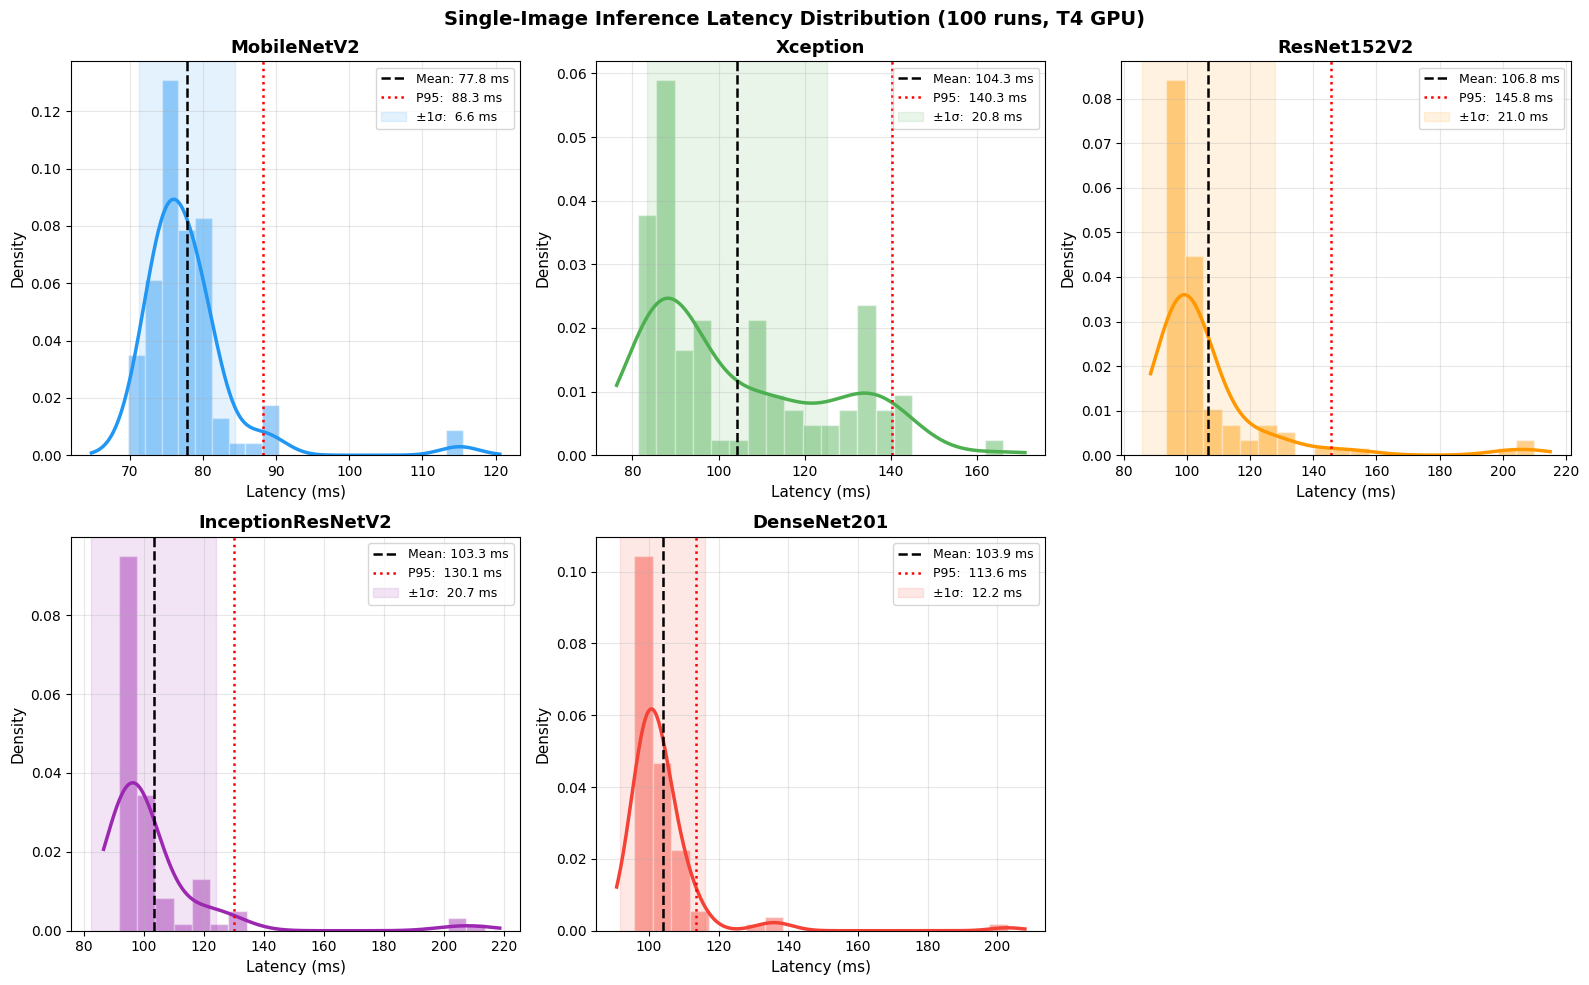

✅ Saved: plot1_individual.png


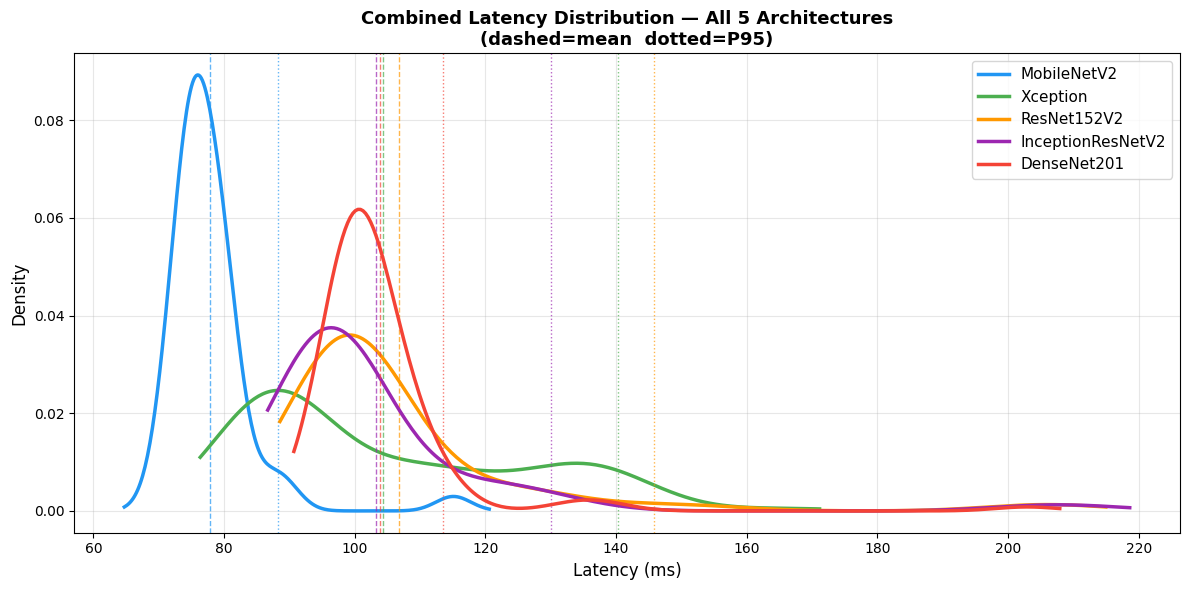

✅ Saved: plot2_combined.png


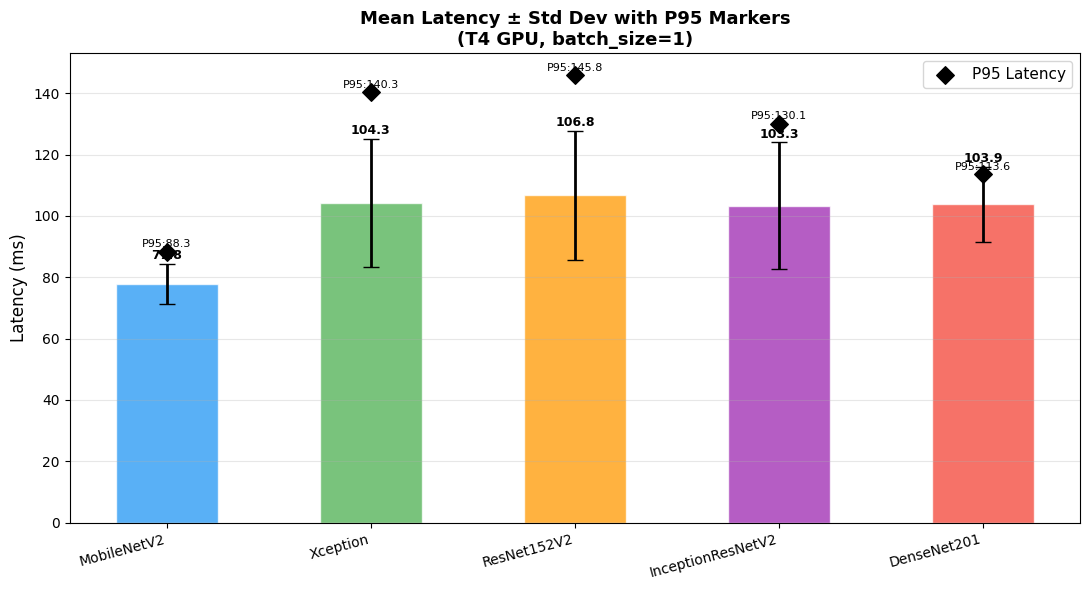

✅ Saved: plot3_barchart.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# ── Load all saved latency values ────────────────────────
base = "/content/drive/MyDrive/Cataract/"

models = {
    'MobileNetV2':       np.load(base + 'latency_MobileNetV2.npy'),
    'Xception':          np.load(base + 'latency_Xception.npy'),
    'ResNet152V2':       np.load(base + 'latency_ResNet152V2.npy'),
    'InceptionResNetV2': np.load(base + 'latency_InceptionResNetV2.npy'),
    'DenseNet201':       np.load(base + 'latency_DenseNet201.npy'),
}

colors = {
    'MobileNetV2':       '#2196F3',
    'Xception':          '#4CAF50',
    'ResNet152V2':       '#FF9800',
    'InceptionResNetV2': '#9C27B0',
    'DenseNet201':       '#F44336',
}

# ── Stats table ───────────────────────────────────────────
print(f"{'Model':<20} {'Mean':>7} {'Std':>7} {'Median':>7} {'P95':>7} {'Min':>7} {'Max':>7} {'CV%':>7}")
print("-" * 75)
for name, times in models.items():
    mean   = np.mean(times)
    std    = np.std(times)
    median = np.median(times)
    p95    = np.percentile(times, 95)
    mn     = np.min(times)
    mx     = np.max(times)
    cv     = (std / mean) * 100
    print(f"{name:<20} {mean:>7.2f} {std:>7.2f} {median:>7.2f} {p95:>7.2f} {mn:>7.2f} {mx:>7.2f} {cv:>7.2f}")

# ── Plot 1: Individual plots ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, times) in enumerate(models.items()):
    ax     = axes[idx]
    mean   = np.mean(times)
    std    = np.std(times)
    p95    = np.percentile(times, 95)

    ax.hist(times, bins=20, color=colors[name], alpha=0.45,
            edgecolor='white', density=True)
    kde = stats.gaussian_kde(times)
    x   = np.linspace(min(times)-5, max(times)+5, 300)
    ax.plot(x, kde(x), color=colors[name], linewidth=2.5)
    ax.axvline(mean, color='black', linestyle='--', linewidth=1.8,
               label=f'Mean: {mean:.1f} ms')
    ax.axvline(p95,  color='red',   linestyle=':',  linewidth=1.8,
               label=f'P95:  {p95:.1f} ms')
    ax.axvspan(mean-std, mean+std, alpha=0.12, color=colors[name],
               label=f'±1σ:  {std:.1f} ms')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Latency (ms)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.suptitle('Single-Image Inference Latency Distribution (100 runs, T4 GPU)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(base + 'plot1_individual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot1_individual.png")

# ── Plot 2: Combined KDE ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
for name, times in models.items():
    mean = np.mean(times)
    p95  = np.percentile(times, 95)
    kde  = stats.gaussian_kde(times)
    x    = np.linspace(min(times)-5, max(times)+5, 300)
    ax.plot(x, kde(x), color=colors[name], linewidth=2.5, label=name)
    ax.axvline(mean, color=colors[name], linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(p95,  color=colors[name], linestyle=':',  linewidth=1, alpha=0.7)

ax.set_xlabel('Latency (ms)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Combined Latency Distribution — All 5 Architectures\n(dashed=mean  dotted=P95)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(base + 'plot2_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot2_combined.png")

# ── Plot 3: Bar chart with error bars ─────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
names = list(models.keys())
means = [np.mean(models[n])          for n in names]
stds  = [np.std(models[n])           for n in names]
p95s  = [np.percentile(models[n],95) for n in names]
clrs  = [colors[n]                   for n in names]
x     = np.arange(len(names))

ax.bar(x, means, yerr=stds, color=clrs, alpha=0.75, capsize=6,
       error_kw={'linewidth':2}, edgecolor='white', width=0.5)
ax.scatter(x, p95s, color='black', zorder=5, s=80,
           marker='D', label='P95 Latency')

for i, (m, s, p) in enumerate(zip(means, stds, p95s)):
    ax.text(i, m+s+1.5, f'{m:.1f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i, p+1.5,   f'P95:{p:.1f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Latency (ms)', fontsize=12)
ax.set_title('Mean Latency ± Std Dev with P95 Markers\n(T4 GPU, batch_size=1)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(base + 'plot3_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot3_barchart.png")